This notebook is inteded to show the results of the following experiment:
- Observed model: InstructBLIP 7B 
- Auxiliary model: MLP
- Dataset: Agriculture

Imports

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

import json
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path
from PIL import Image
from sklearn.metrics import f1_score
from texttable import Texttable
import pandas as pd


Dataset Show Off

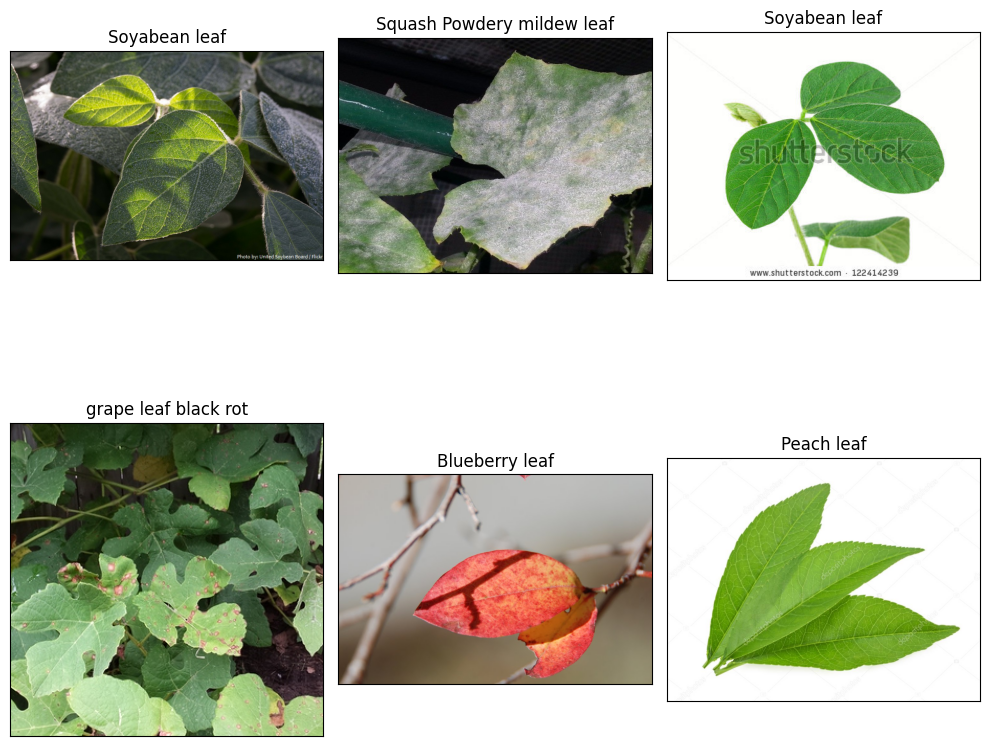

In [2]:
train_dataset = json.load(open('../../datasets/agri_train.json', 'r'))['img_paths']
val_dataset = json.load(open('../../datasets/agri_val.json', 'r'))['img_paths']
test_dataset = json.load(open('../../datasets/agri_test.json', 'r'))['img_paths']

fig, axes = plt.subplots(2, 3, figsize=(10,10))
for i, ax in enumerate(axes.flat):
    index = int(random.uniform(0,1)*len(train_dataset))
    img_path = train_dataset[index]
    ax.imshow(np.array(Image.open(img_path)))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(img_path.split(os.sep)[-2], fontsize=12)
plt.tight_layout()
plt.show()

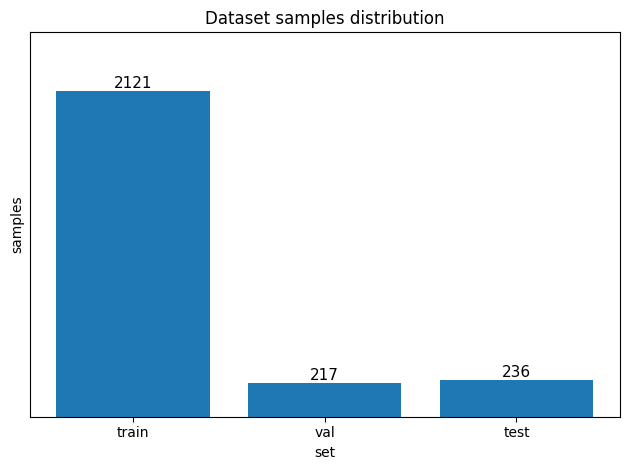

In [3]:
train_samples = len(train_dataset)
val_samples = len(val_dataset)
test_samples = len(test_dataset)
values = [train_samples, val_samples, test_samples]

fig, ax = plt.subplots()
ax.set_ylim(0,2500)
ax.set_title('Dataset samples distribution', fontsize=12)
# ax.set_xticks([])
ax.set_yticks([])
bars = ax.bar(['train', 'val', 'test'], values)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{height}', 
            ha='center', va='bottom', fontsize=11)
ax.set_ylabel('samples')
ax.set_xlabel('set')
plt.tight_layout()
plt.show()

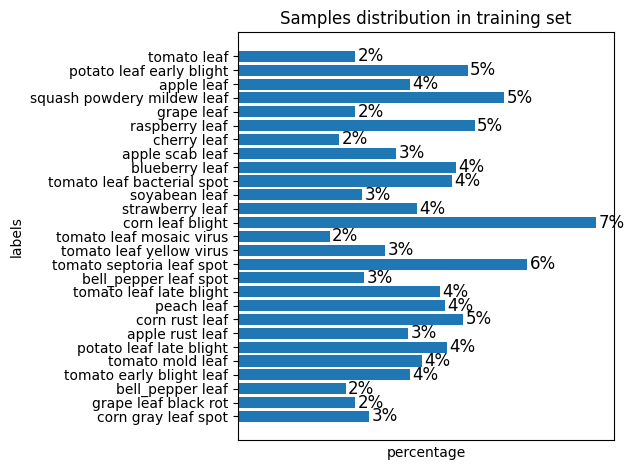

In [4]:
labels = {}
for path in train_dataset:
    key = path.split(os.sep)[-2].lower()
    labels[key] = labels.get(key, 0) + 100/len(train_dataset)

keys = list(labels.keys())
values = list(labels.values())
plt.xticks([])
plt.barh(keys, values)
for index, value in enumerate(values):
    plt.text(value+0.05, index, f"{value:.0f}%", va='center', fontsize=12)  # Adjust `+1` for spacing
plt.title("Samples distribution in training set", fontsize=12)
plt.ylabel('labels')
plt.xlabel('percentage')
plt.tight_layout()
plt.show()

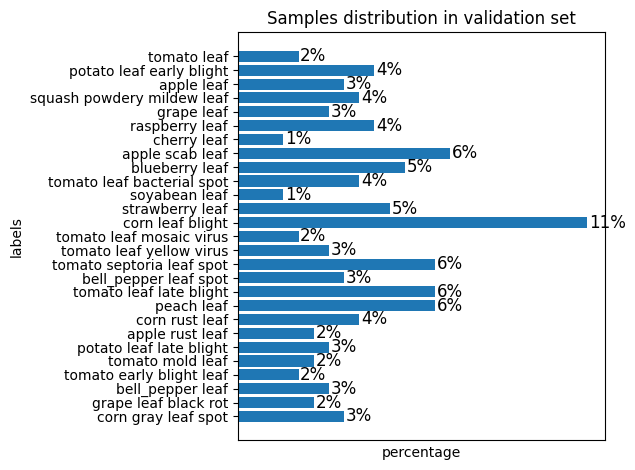

In [5]:
labels = {}
for path in val_dataset:
    key = path.split(os.sep)[-2].lower()
    labels[key] = labels.get(key, 0) + 100/len(val_dataset)

keys = list(labels.keys())
values = list(labels.values())
plt.xticks([])
plt.barh(keys, values)
for index, value in enumerate(values):
    plt.text(value+0.05, index, f"{value:.0f}%", va='center', fontsize=12)  # Adjust `+1` for spacing
plt.title("Samples distribution in validation set", fontsize=12)
plt.ylabel('labels')
plt.xlabel('percentage')
plt.tight_layout()
plt.show()

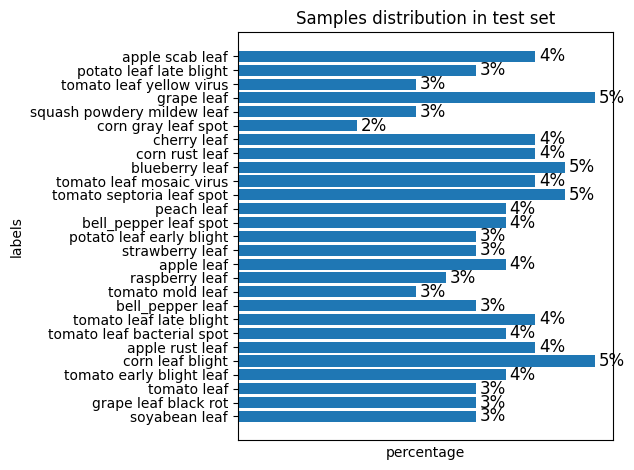

In [6]:
labels = {}
for path in test_dataset:
    key = path.split(os.sep)[-2].lower()
    labels[key] = labels.get(key, 0) + 100/len(test_dataset)

keys = list(labels.keys())
values = list(labels.values())
plt.xticks([])
plt.barh(keys, values)
for index, value in enumerate(values):
    plt.text(value+0.05, index, f"{value:.0f}%", va='center', fontsize=12)  # Adjust `+1` for spacing
plt.title("Samples distribution in test set", fontsize=12)
plt.ylabel('labels')
plt.xlabel('percentage')
plt.tight_layout()
plt.show()

Training

In [7]:
pre_train_files = [str(f) for f in Path('./pre/train').rglob('*.json')]
pre_train_files.sort()
pre_train_results = [json.load(open(f)) for f in pre_train_files]

post_train_files = [str(f) for f in Path('./post/train').rglob('*.json')]
post_train_files.sort()
post_train_results = [json.load(open(f)) for f in post_train_files]


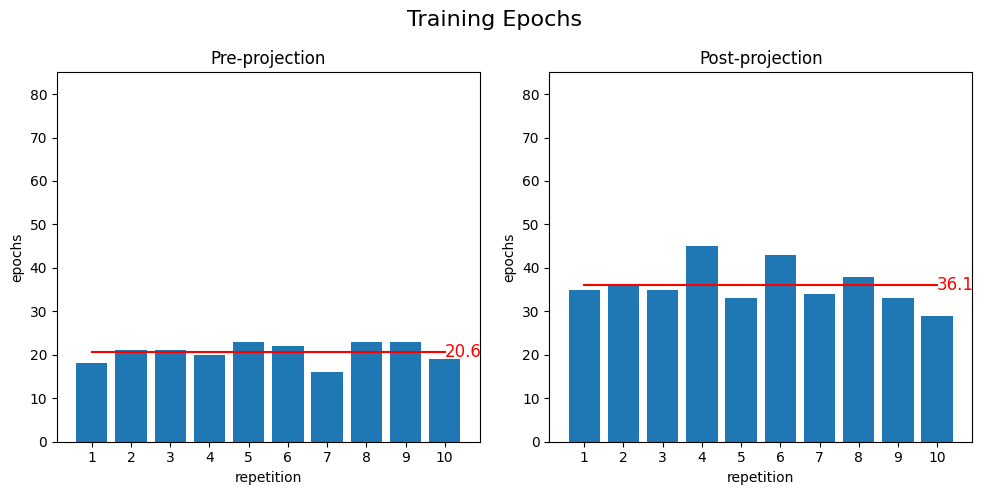

In [8]:
pre_epochs = [result['epoch'] for result in pre_train_results]
post_epochs = [result['epoch'] for result in post_train_results]
x = [i+1 for i, _ in enumerate(pre_epochs)]

pre_avg = [np.mean(np.array(pre_epochs)) for _ in pre_epochs]
post_avg = [np.mean(np.array(post_epochs)) for _ in post_epochs]

fig, axes = plt.subplots(1, 2, figsize=(10,5))
fig.suptitle("Training Epochs", fontsize=16)
# chart 1
axes[0].bar(x, pre_epochs)
axes[0].set_ylim(0, 85)
axes[0].plot(x, pre_avg, color='red')
axes[0].set_title('Pre-projection')
axes[0].set_ylabel('epochs')
axes[0].set_xlabel('repetition')
axes[0].set_xticks(x)
axes[0].text(x[-1], pre_avg[-1], f"{pre_avg[-1]:.1f}", fontsize=12, color='red', verticalalignment='center')

# chart 2
axes[1].bar(x, post_epochs)
axes[1].set_ylim(0, 85)
axes[1].plot(x, post_avg, color='red')
axes[1].set_title('Post-projection')
axes[1].set_ylabel('epochs')
axes[1].set_xlabel('repetition')
axes[1].set_xticks(x)
axes[1].text(x[-1], post_avg[-1], f"{post_avg[-1]:.1f}", fontsize=12, color='red', verticalalignment='center')

plt.tight_layout()
plt.show()

In [9]:
pre_train_losses = [result['train_loss'] for result in pre_train_results]
pre_val_losses = [result['val_loss'] for result in pre_train_results]

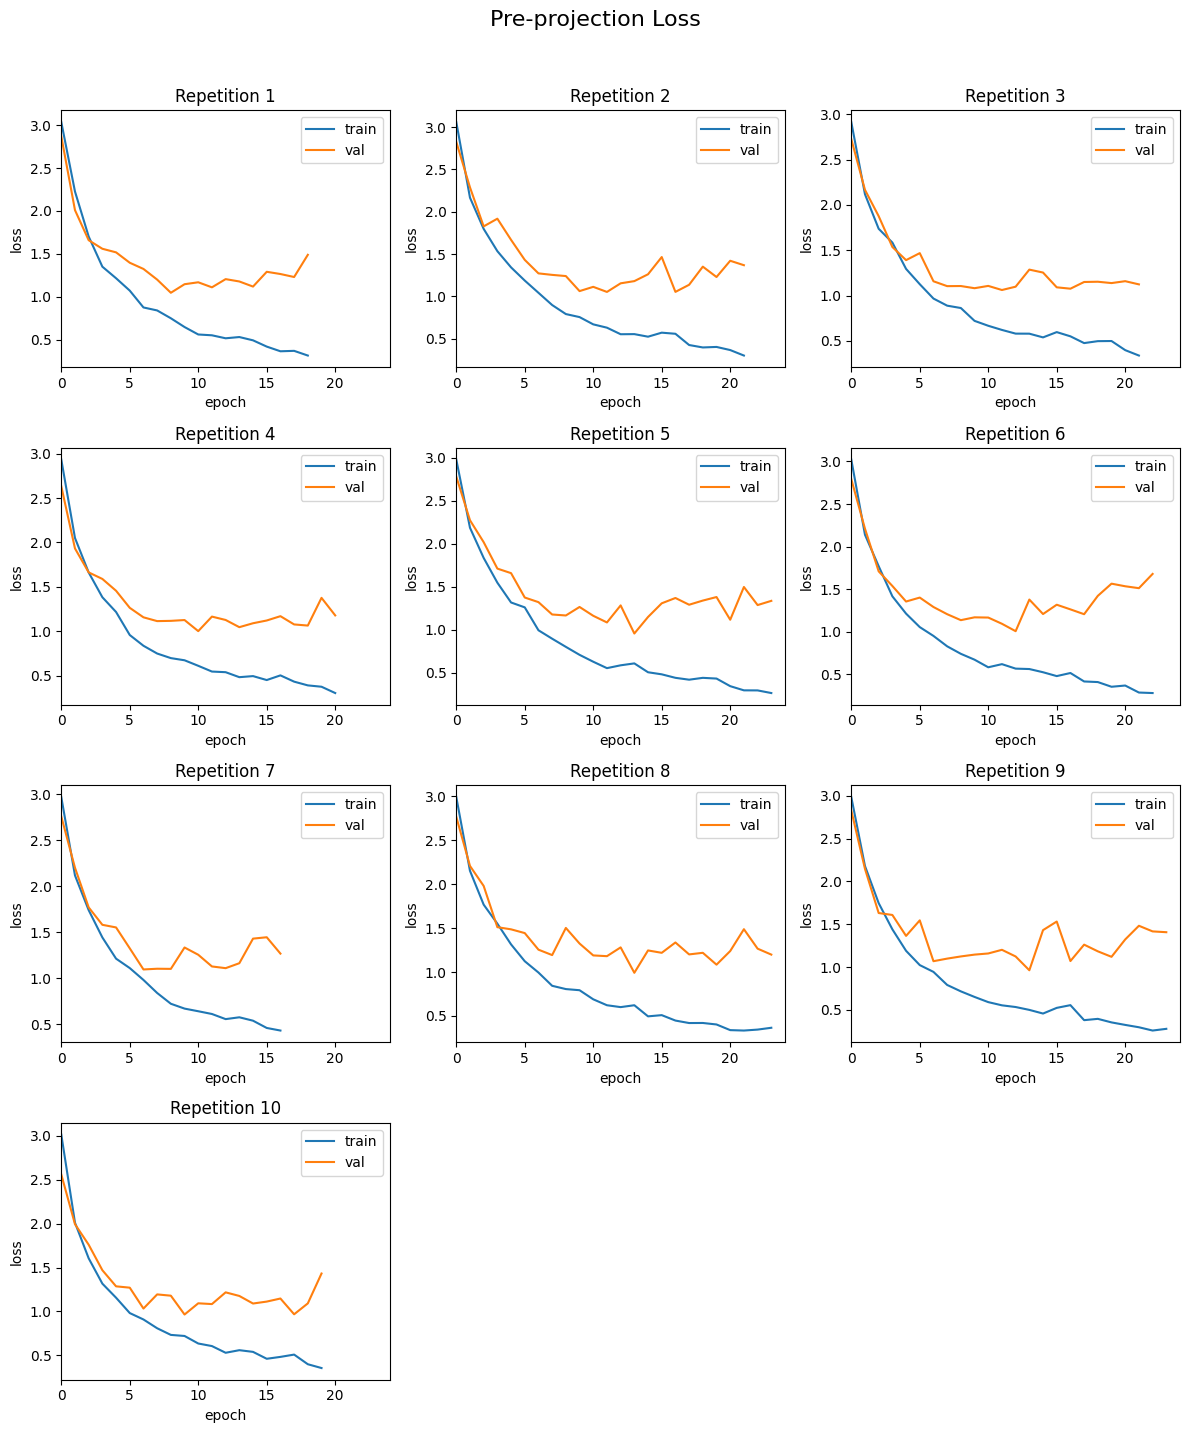

In [10]:
x_maxes = [len(pre_train_loss) for pre_train_loss in pre_train_losses]
x_max = np.max(np.array(x_maxes))

fig, axes = plt.subplots(4, 3, figsize=(12, 14))
fig.suptitle('Pre-projection Loss', fontsize=16, y=1.02)
for i, ax in enumerate(axes.flat):
    if i < len(pre_train_losses):
        ax.plot(pre_train_losses[i], label='train')
        ax.plot(pre_val_losses[i], label='val')
        ax.set_title(f'Repetition {i+1}')
        ax.set_xlim(0, x_max)
        ax.set_xlabel('epoch')
        ax.set_ylabel('loss')
        ax.legend()
    else:
        ax.set_axis_off()


plt.tight_layout()
plt.show()

In [11]:
post_train_losses = [result['train_loss'] for result in post_train_results]
post_val_losses = [result['val_loss'] for result in post_train_results]

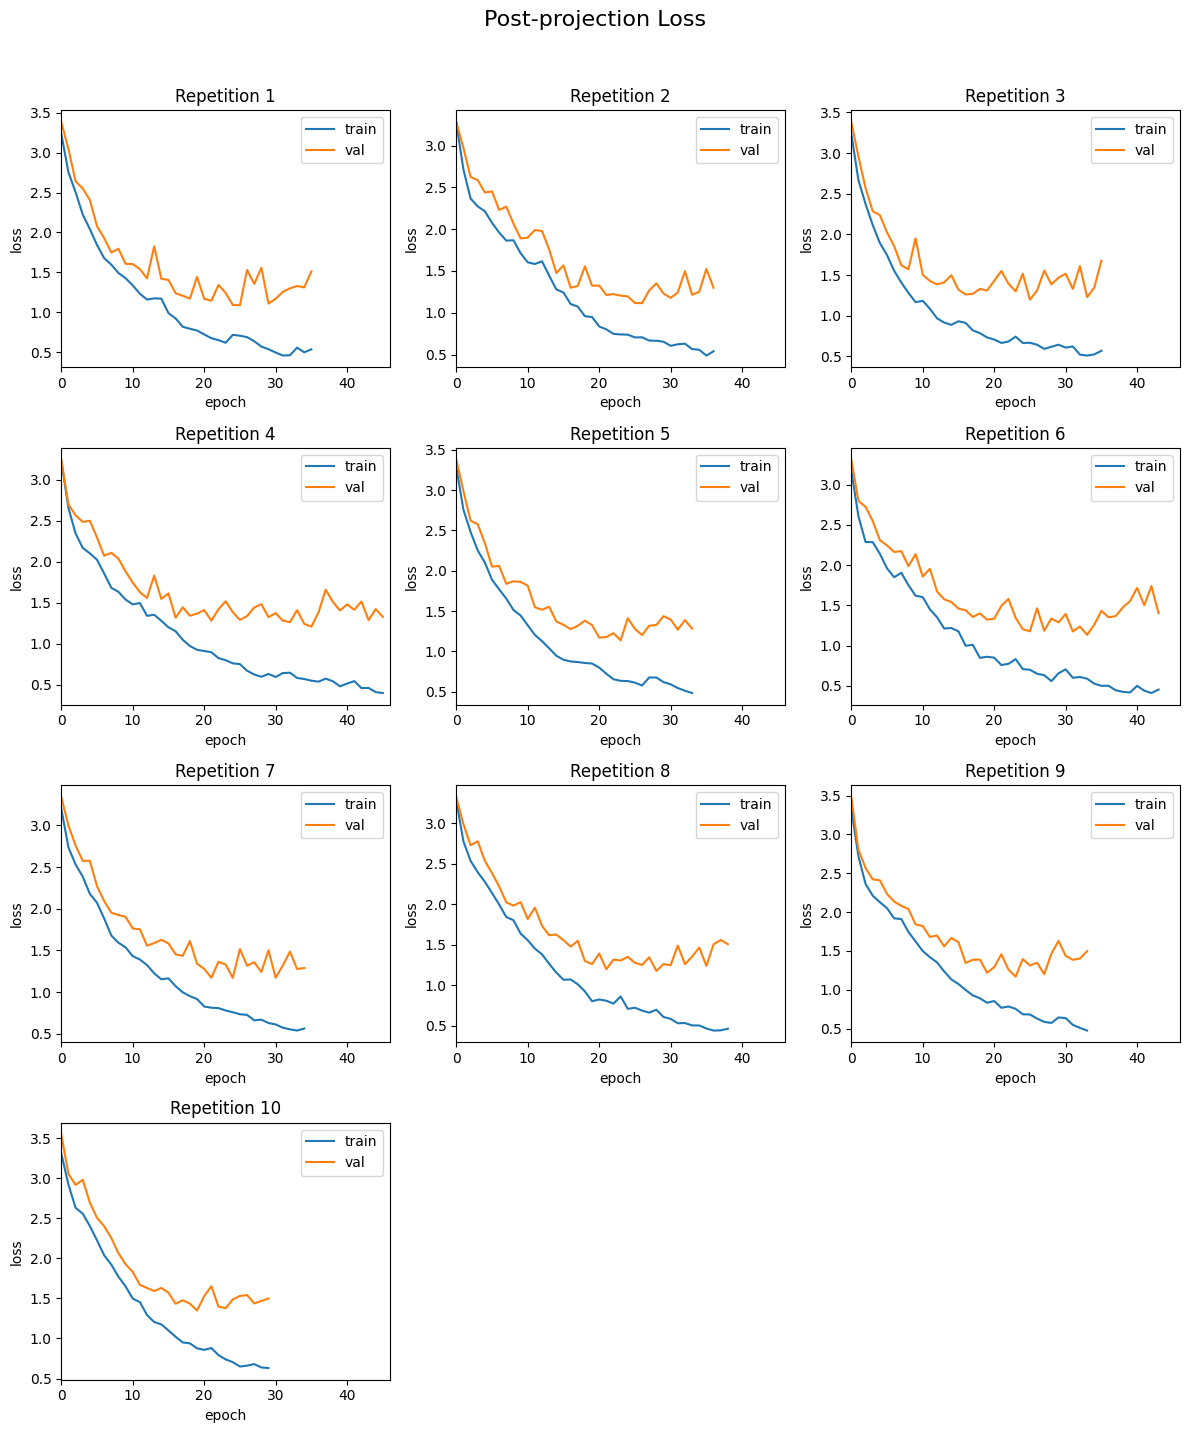

In [12]:
x_maxes = [len(post_train_loss) for post_train_loss in post_train_losses]
x_max = np.max(np.array(x_maxes))

fig, axes = plt.subplots(4, 3, figsize=(12, 14))
fig.suptitle('Post-projection Loss', fontsize=16, y=1.02)
for i, ax in enumerate(axes.flat):
    if i < len(post_train_losses):
        ax.plot(post_train_losses[i], label='train')
        ax.plot(post_val_losses[i], label='val')
        ax.set_title(f'Repetition {i+1}')
        ax.set_xlim(0, x_max)
        ax.set_xlabel('epoch')
        ax.set_ylabel('loss')
        ax.legend()
    else:
        ax.set_axis_off()

plt.tight_layout()
plt.show()

Testing

In [13]:
pre_test_files = [str(f) for f in Path('./pre/test').rglob('*.json')]
pre_test_files.sort()
pre_test_results = [json.load(open(f)) for f in pre_test_files]

post_test_files = [str(f) for f in Path('./post/test').rglob('*.json')]
post_test_files.sort()
post_test_results = [json.load(open(f)) for f in post_test_files]

pre_accuracies = [result['eval_accuracy'] for result in pre_test_results]
pre_gts = [result['gts'] for result in pre_test_results]
pre_preds = [result['preds'] for result in pre_test_results]
pre_labels = [result['labels'] for result in pre_test_results]
pre_f1_scores = [f1_score(np.array(pre_gts[i]), np.array(pre_preds[i]), average='macro') for i, _ in enumerate(pre_gts)]

post_accuracies = [result['eval_accuracy'] for result in post_test_results]
post_gts = [result['gts'] for result in post_test_results]
post_preds = [result['preds'] for result in post_test_results]
post_labels = [result['labels'] for result in post_test_results]
post_f1_scores = [f1_score(np.array(post_gts[i]), np.array(post_preds[i]), average='macro') for i, _ in enumerate(pre_gts)]

pat = pre_train_results[0]['patience_limit']

exp_name = str(os.path.abspath('.')).split(os.sep)[-1]

data = {
    exp_name: [],
    'Pre-proj acc': [],
    'Pre-proj F1': [],
    'Pre-proj epochs': [],
    'Post-proj acc': [],
    'Post-proj F1': [],
    'Post-proj epochs': [],
}

for i in range(len(pre_accuracies)):
    data[exp_name].append(f"repetition {i+1}")
    data['Pre-proj acc'].append(pre_accuracies[i])
    data['Pre-proj F1'].append(pre_f1_scores[i])
    data['Pre-proj epochs'].append(pre_epochs[i])
    data['Post-proj acc'].append(post_accuracies[i])
    data['Post-proj F1'].append(post_f1_scores[i])
    data['Post-proj epochs'].append(post_epochs[i])

df = pd.DataFrame(data)
model_dataset = str(os.path.abspath('.')).split(os.sep)[-2]
exp = str(os.path.abspath('.')).split(os.sep)[-1].split('_')[0]

try:
    with pd.ExcelWriter(f"../../results.xlsx", engine='openpyxl', mode='a', if_sheet_exists='overlay') as writer:
        df.to_excel(writer, sheet_name=f"{model_dataset}-{exp}", index=False)
except FileNotFoundError:
    # If the file does not exist, create a new one
    with pd.ExcelWriter(f"../../results.xlsx", engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name=f"{model_dataset}-{exp}", index=False)
